<a href="https://colab.research.google.com/github/MohammedElata/meta-vs-tiktok-als-vs-autorec/blob/main/notebooks/meta_vs_tiktok_recommender_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Installing Implicit and all the necessary Libarires
!pip -q install implicit

import os, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
#Setting Seed at 42 to get the same split from random for reproducibility
Seed = 42
random.seed(Seed); np.random.seed(Seed); torch.manual_seed(Seed)

#Choosing Hardware for this python coding
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device used: ", device)

Device used:  cpu


In [ ]:
#importing Movie Lens 100K dataset from Google colab
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/datasets/ml-100k.zip"
!unzip /content/drive/MyDrive/datasets/ml-100k.zip -d /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/datasets/ml-100k.zip
replace /content/ml-100k/allbut.pl? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/ml-100k/allbut.pl  
replace /content/ml-100k/mku.sh? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/ml-100k/mku.sh  
replace /content/ml-100k/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/ml-100k/README  
replace /content/ml-100k/u.data? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/ml-100k/u.data  
replace /content/ml-100k/u.genre? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/ml-100k/u.genre  
replace /content/ml-100k/u.info? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/ml-100k/u.info  
replace /content/ml-100k/u.item? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/ml-100k/u.item  
replace /content/ml-100k/

In [ ]:
#Defining the columns and merging the dataset into one dataframe
columns = ['user_id', 'item_id', 'rating', 'timestamp']
movie_df = pd.read_csv('/content/ml-100k/u.data', sep='\t', names=columns)

movie_dataset = pd.read_csv('/content/ml-100k/u.item', sep='|', encoding='latin-1', header=None)
movie_dataset = movie_dataset[[0, 1]]; movie_dataset.columns = ['item_id', 'title']

movie_df = movie_df.merge(movie_dataset, on='item_id')
movie_df.head()

,user_id,item_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [ ]:
#Splitting the dataset into training and testing split with random_state = Seed
train_df, test_df = train_test_split(movie_df, test_size=0.2, random_state=Seed)

#sorting and creating ID for Users and Items
train_users = np.sort(train_df['user_id'].unique())
train_items = np.sort(train_df['item_id'].unique())

#Create user and item mappings for sparse matrix
user_mappings = {u:i for i,u in enumerate(train_users)}
item_mappings = {m:i for i,m in enumerate(train_items)}

#Adding new columns to the dataframe and replace the orignal user and items IDs
train_df = train_df.assign(
    new_user_id=train_df['user_id'].map(user_mappings),
    new_item_id=train_df['item_id'].map(item_mappings),
)

#removing user and items from testing that isnt in training to avoid cold start issues
test_df = test_df[test_df['user_id'].isin(train_users) & test_df['item_id'].isin(train_items)].copy()

#Adding new columns to the training dataset
test_df['new_user_id'] = test_df['user_id'].map(user_mappings)
test_df['new_item_id'] = test_df['item_id'].map(item_mappings)


num_users, num_items = len(train_users), len(train_items)
print(f"Users={num_users}, Items={num_items}, Train={len(train_df)}, Test={len(test_df)}")

train_items_by = train_df.groupby('new_user_id')['new_item_id'].apply(set).to_dict()
test_items_by  = test_df.groupby('new_user_id')['new_item_id'].apply(set).to_dict()

Users=943, Items=1653, Train=80000, Test=19969


In [ ]:
#First function to measure ranking quaility for the metrics
def _dcg_ranking(hits):
    return sum(hits[j] / math.log2(j + 2) for j in range(len(hits)))


def all_topk_metrics(score_mat, k=10):
    """This function is used to compute all metrics which are, Precision@k, Recall@k, NDCG@k."""
    #empty string for metric values
    precision, recall, ndcgs = [], [], []
    #for loop for each suer in the test_items
    for each_user, true_items in test_items_by.items():
        if len(true_items) == 0:
            continue
        #predicted scores
        p_scores = score_mat[each_user].copy()
        seen = train_items_by.get(each_user, set())
        if seen:
            p_scores[list(seen)] = -np.inf
        #selecting the top_k items
        topk_score = np.argpartition(p_scores, -k)[-k:]
        topk_score = topk_score[np.argsort(p_scores[topk_score])[::-1]]
        ##calucate metrics
        hits = [1 if i in true_items else 0 for i in topk_score]
        #precison and recall scores
        precision.append(sum(hits)/k)
        recall.append(sum(hits)/len(true_items))
        #NDCG score
        ideal_ranking = [1]*min(k, len(true_items)) + [0]*max(0, k-len(true_items))
        ndcgs.append(_dcg_ranking(hits) / max(_dcg_ranking(ideal_ranking), 1e-9))

    return float(np.mean(precision)), float(np.mean(recall)), float(np.mean(ndcgs))

def coverage(score_mat, k=10):
    """Beyond Accuacy metrics Function"""
    recommended_items = set()
    #a loop to for each user
    for each_user in test_items_by.keys():
        p_scores = score_mat[each_user].copy()
        seen = train_items_by.get(each_user, set())
        if seen:
            p_scores[list(seen)] = -np.inf
        topk_score = np.argpartition(p_scores, -k)[-k:]
        recommended_items.update(topk_score)
    return len(recommended_items) / score_mat.shape[1]

def diversity(score_mat, item_emb, k=10):
    """ Diversity metric"""
    #importing norm to help calucate vector levsl and store diversity values
    from numpy.linalg import norm
    vals = []
    #loop for the testing test though each user
    for each_user in test_items_by.keys():
        scores = score_mat[each_user].copy()
        seen = train_items_by.get(each_user, set())
        if seen:
            scores[list(seen)] = -np.inf
        #selecting the top_k scores from the predicted scores
        topk_score = np.argpartition(scores, -k)[-k:]
        topk_score = topk_score[np.argsort(scores[topk_score])[::-1]]
        if len(topk_score) < 2:
            continue

        embeddings = item_emb[topk_score]
        norms = np.maximum(1e-9, norm(embeddings, axis=1))
        cos = (embeddings @ embeddings.T) / (norms[:,None] * norms[None,:])
        upper = np.triu_indices(k, 1)
        sim_mean = cos[upper].mean()
        vals.append(1 - sim_mean)
    return float(np.mean(vals)) if vals else 0.0

In [ ]:
import implicit

v_als = (train_df['rating'] >= 4).astype(np.float32)
C = sp.csr_matrix((v_als, (train_df['new_user_id'], train_df['new_item_id'])),
                  shape=(num_users, num_items))

als = implicit.als.AlternatingLeastSquares(
    factors=64, regularization=0.08, iterations=20, random_state=Seed
)
als.fit(C * 40.0)

U_als, V_als = als.user_factors, als.item_factors
scores_als   = U_als @ V_als.T

rmse_als = np.sqrt(
    mean_squared_error(
        test_df['rating'],
        (U_als[test_df['new_user_id']] * V_als[test_df['new_item_id']]).sum(axis=1)
    )
)
p_als, r_als, ndcg_als = all_topk_metrics(scores_als, k=10)
cov_als = coverage(scores_als, k=10)
div_als = diversity(scores_als, V_als, k=10)

print(f"[ALS] RMSE={rmse_als:.4f}  Precision@10={p_als:.4f}  Recall@10={r_als:.4f}  NDCG@10={ndcg_als:.4f}  "
      f"Coverage={cov_als:.3f}  Diversity={div_als:.3f}")

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

[ALS] RMSE=3.2916  Precision@10=0.2344  Recall@10=0.1601  NDCG@10=0.2794  Coverage=0.384  Diversity=0.907


In [ ]:
#The validation set from the training dataset for each user
val_id_set = train_df.groupby('new_user_id').tail(1).index
val_df  = train_df.loc[val_id_set]
trn_df  = train_df.drop(val_id_set)

#This code builds a matrix of a dense user/item for the AutoRec model
R = np.zeros((num_users, num_items), dtype=np.float32)
for r in trn_df.itertuples():
    R[r.new_user_id, r.new_item_id] = r.rating
R_t = torch.tensor(R, device=device)

val_pairs = [(r.new_user_id, r.new_item_id, r.rating) for r in val_df.itertuples()]

#training loop for the AutoRec Model
class AutoRec_model(nn.Module):
    def __init__(self, n_items, hidden=200, drop=0.4):
        super().__init__()
        #usining an encoder, ReLU activation function with a dropout and a Decoder for the vectors
        self.enc = nn.Sequential(nn.Linear(n_items, hidden), nn.ReLU(), nn.Dropout(drop))
        self.dec = nn.Linear(hidden, n_items)
    def forward(self, x): return self.dec(self.enc(x))

#training features of adam optimiser and MSE
ar   = AutoRec_model(num_items, hidden=200, drop=0.4).to(device)
opt  = optim.Adam(ar.parameters(), lr=5e-4, weight_decay=1e-5)
crit = nn.MSELoss()


best_val = 1e9
patience, bad = 8, 0
train_losses, val_rmse_curve = [], []

#loop for each epochs
for epoch in range(100):
    ar.train(); opt.zero_grad()
    out = ar(R_t)
    loss = crit(out[R_t>0], R_t[R_t>0])
    loss.backward(); opt.step()
    train_losses.append(float(loss.item()))

    # validating the training loop
    ar.eval()
    with torch.no_grad():
        vpred = [out[u, i].item() for (u,i,_) in val_pairs]
        vtrue = [r for (_,_,r) in val_pairs]
    rmse_val = float(np.sqrt(((np.array(vpred) - np.array(vtrue))**2).mean()))
    val_rmse_curve.append(rmse_val)

    # adding overfitting to avoid overfitting
    if rmse_val < best_val:
        best_val, bad = rmse_val, 0
        best_state = {k: v.cpu().clone() for k, v in ar.state_dict().items()}
    else:
        bad += 1
        if bad >= patience:
            break

# save the best model
ar.load_state_dict({k: v.to(device) for k, v in best_state.items()})
ar.eval()
with torch.no_grad():
    scores_ar = ar(R_t).cpu().numpy()

# Testing and making the RMSE score
preds_ar = [scores_ar[u, i] for u, i in zip(test_df['new_user_id'], test_df['new_item_id'])]
rmse_ar = np.sqrt(mean_squared_error(test_df['rating'], preds_ar))

#item embeddings for diversity on one-hot item
I = np.eye(num_items, dtype=np.float32)
codes = []
bs = 512
for s in range(0, num_items, bs):
    batch = torch.tensor(I[s:s+bs], device=device)
    with torch.no_grad():
        codes.append(ar.enc(batch).cpu().numpy())
item_codes = np.vstack(codes)

#computing the metrics
p_ar, r_ar, ndcg_ar = all_topk_metrics(scores_ar, k=10)
cov_ar = coverage(scores_ar, k=10)
div_ar = diversity(scores_ar, item_codes, k=10)
#print all the metrics
print(f"[AutoRec] RMSE={rmse_ar:.4f}  Precison@10={p_ar:.4f}  Recall@10={r_ar:.4f}  NDCG@10={ndcg_ar:.4f}  "
      f"Coverage={cov_ar:.3f}  Diversity={div_ar:.3f}")


[AutoRec] RMSE=1.1732  Precison@10=0.0413  Recall@10=0.0359  NDCG@10=0.0392  Coverage=0.211  Diversity=0.102


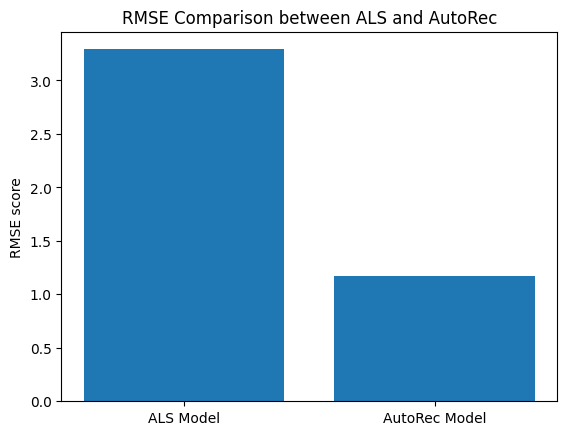

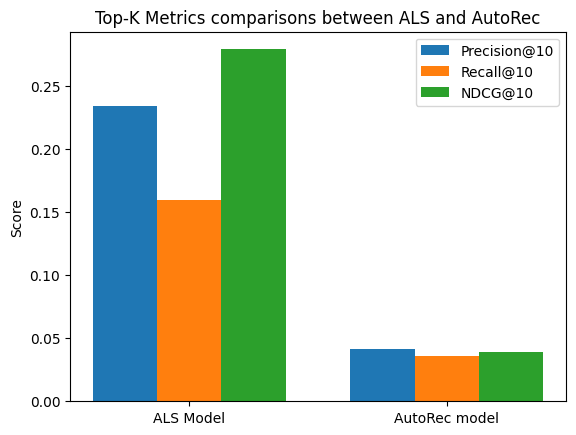

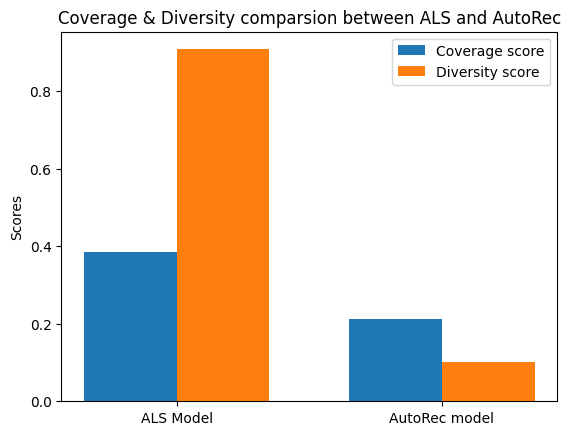

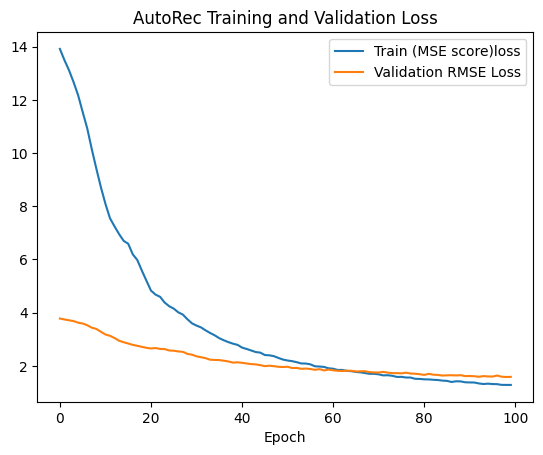

In [ ]:
# comparing RMSE score bar graph
label = ['ALS Model', 'AutoRec Model']
rmse_vals = [rmse_als, rmse_ar]
plt.bar(label, rmse_vals)
plt.ylabel('RMSE score'); plt.title('RMSE Comparison between ALS and AutoRec'); plt.show()

# Top-K metrics graph
label = ['ALS Model', 'AutoRec model']
prec_vals = [p_als, p_ar]
rec_vals  = [r_als, r_ar]
ndcg_vals = [ndcg_als, ndcg_ar]
x = np.arange(len(label)); w = 0.25
plt.bar(x - w, prec_vals, w, label='Precision@10')
plt.bar(x,      rec_vals,  w, label='Recall@10')
plt.bar(x + w,  ndcg_vals, w, label='NDCG@10')
plt.xticks(x, label); plt.ylabel('Score'); plt.title('Top-K Metrics comparisons between ALS and AutoRec'); plt.legend(); plt.show()

# coverage and diverity comparison graph
cov_vals = [cov_als, cov_ar]
div_vals = [div_als, div_ar]
x = np.arange(len(label)); w = 0.35
plt.bar(x - w/2, cov_vals, w, label='Coverage score')
plt.bar(x + w/2, div_vals, w, label='Diversity score')
plt.xticks(x, label); plt.ylabel('Scores'); plt.title('Coverage & Diversity comparsion between ALS and AutoRec'); plt.legend(); plt.show()

# AutoRec training loss line graph
plt.plot(train_losses, label='Train (MSE score)loss')
plt.plot(val_rmse_curve, label='Validation RMSE Loss')
plt.xlabel('Epoch'); plt.title('AutoRec Training and Validation Loss'); plt.legend(); plt.show()


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

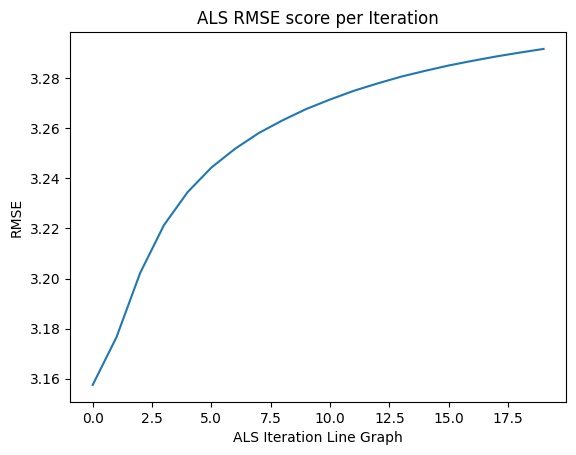

In [ ]:
#ALS RMSE score per iteration of epochs
als_iter = implicit.als.AlternatingLeastSquares(
    factors=64, regularization=0.08, iterations=1, random_state=Seed
)
rmse_curve, loss_curve = [], []
C_scaled = C * 40.0

for _ in range(20):
    als_iter.fit(C_scaled)
    U, V = als_iter.user_factors, als_iter.item_factors
    preds = (U[test_df['new_user_id']] * V[test_df['new_item_id']]).sum(axis=1)
    rmse_curve.append(np.sqrt(mean_squared_error(test_df['rating'], preds)))


plt.plot(rmse_curve); plt.xlabel("ALS Iteration Line Graph"); plt.ylabel("RMSE"); plt.title("ALS RMSE score per Iteration"); plt.show()